<a href="https://colab.research.google.com/github/anushrikaduskar1306-prog/Practical-No-1/blob/main/Task_9_EE503.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
#print(np.__version__)

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
weight_list = []
bias_list = []

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        weight_list.append(self.weights)
        bias_list.append(self.bias)

        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

In [ ]:
X = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
Y =  np.array([1.2, 1.4, 1.55, 1.75, 2.01, 2.2, 2.35])

network = [
    Dense(1, 1),
    Linear()
]

epochs = 100
learning_rate = 0.5
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)

    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(100, error=1.3759709561150435
2/(100, error=2.944523457638765
3/(100, error=2.1158955970913005
4/(100, error=1.522241357553065
5/(100, error=1.0967556507823526
6/(100, error=0.7916548863644347
7/(100, error=0.5727553637699959
8/(100, error=0.41559904374661255
9/(100, error=0.3026835220960254
10/(100, error=0.22148141070999997
11/(100, error=0.16302408811535096
12/(100, error=0.1208889446730729
13/(100, error=0.09047511461203801
14/(100, error=0.06848547552648643
15/(100, error=0.05255613529571848
16/(100, error=0.04099138253844427
17/(100, error=0.03257405540238531
18/(100, error=0.026429846983084915
19/(100, error=0.02193018776998836
20/(100, error=0.018622722350653834
21/(100, error=0.016181526783177642
22/(100, error=0.014371450295309583
23/(100, error=0.013022564577146898
24/(100, error=0.012011847685901399
25/(100, error=0.011250047427577934
26/(100, error=0.010672253921175127
27/(100, error=0.010231129299389985
28/(100, error=0.009892041634697455
29/(100, error=0.0096295641446

In [ ]:
X1 = [0.15]

for x in X1:
    output = x
    for layer in network:
        output=layer.forward(output)
    print(output)

[[1.31024375]]


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
w = weight_list[100][0][0]

In [ ]:
b = bias_list[100][0][0]

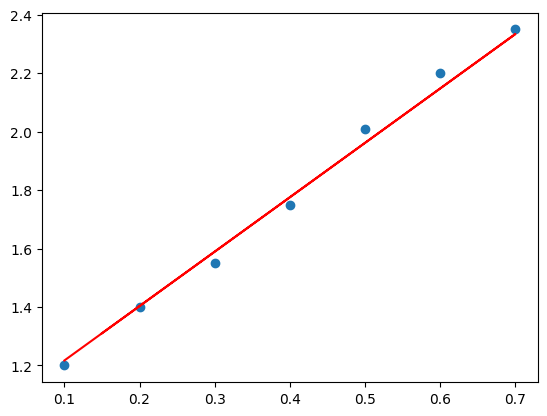

In [ ]:
plt.scatter(X,Y)

x1 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.15]
y1 = [(w*i + b) for i in x1]
plt.plot(x1, y1, color='r')